# Earthquake Exploratory Data Analysis (USGS)

This notebook performs exploratory data analysis on earthquake events extracted from the USGS Earthquake Hazards API.
Analysis covers dataset properties, magnitude distributions, event depth trends, magnitude vs depth relationships, seismic category breakdowns, and geographic map distributions.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for charts
sns.set_theme(style='whitegrid', palette='magma')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load processed USGS data
processed_path = '../data/processed/usgs/usgs_processed.csv'
if not os.path.exists(processed_path):
    processed_path = '../data/processed/usgs/usgs_processed.parquet'

if processed_path.endswith('.parquet'):
    df_eq = pd.read_parquet(processed_path)
else:
    df_eq = pd.read_csv(processed_path)

print(f'Successfully loaded {len(df_eq)} earthquake event records. Columns: {list(df_eq.columns)}')

Successfully loaded 1000 earthquake event records. Columns: ['event_id', 'event_time', 'magnitude', 'magnitude_type', 'place', 'region', 'longitude', 'latitude', 'depth_km', 'magnitude_category', 'status', 'event_type', 'tsunami', 'event_url']


## 1. Dataset Overview

In [2]:
print('=== Earthquake Dataset Summary ===')
print(f'Total Events: {len(df_eq)}')
print(f'Date Range: {df_eq["event_time"].min()} to {df_eq["event_time"].max()}')
print(f'Magnitude Range: Min = {df_eq["magnitude"].min()}, Max = {df_eq["magnitude"].max()}, Mean = {df_eq["magnitude"].mean():.2f}')
print(f'Depth Range (km): Min = {df_eq["depth_km"].min()}, Max = {df_eq["depth_km"].max()}, Mean = {df_eq["depth_km"].mean():.2f}')
print(f'Magnitude Types: {df_eq["magnitude_type"].unique().tolist()}')
print(f'Tsunami Alerts Triggered: {df_eq["tsunami"].sum()}')
print(f'Unique Regions: {df_eq["region"].nunique()}')
print('\nData Types:')
print(df_eq.dtypes)

=== Earthquake Dataset Summary ===
Total Events: 1000
Date Range: 2026-08-05T00:25:25Z to 2026-08-19T23:52:45Z
Magnitude Range: Min = 2.5, Max = 7.7, Mean = 3.64
Depth Range (km): Min = -1.73, Max = 655.67, Mean = 45.80
Magnitude Types: ['ml', 'mb', 'mww', 'md', 'mb_lg', 'mw', 'mwr']
Tsunami Alerts Triggered: 0
Unique Regions: 327

Data Types:
event_id                  str
event_time                str
magnitude             float64
magnitude_type            str
place                     str
region                    str
longitude             float64
latitude              float64
depth_km              float64
magnitude_category        str
status                    str
event_type                str
tsunami                 int64
event_url                 str
dtype: object


## 2. Data Quality Analysis

In [3]:
print('=== Missing Values ===')
print(df_eq.isnull().sum())

print('\n=== Duplicate Event ID Check ===')
dups = df_eq.duplicated(subset=['event_id']).sum()
print(f'Duplicate event_id records: {dups}')

print('\n=== Outlier Boundary Check ===')
invalid_coords = ((df_eq['latitude'] < -90) | (df_eq['latitude'] > 90) | (df_eq['longitude'] < -180) | (df_eq['longitude'] > 180)).sum()
print(f'Invalid coordinate records: {invalid_coords}')

=== Missing Values ===
event_id              0
event_time            0
magnitude             0
magnitude_type        0
place                 0
region                0
longitude             0
latitude              0
depth_km              0
magnitude_category    0
status                0
event_type            0
tsunami               0
event_url             0
dtype: int64

=== Duplicate Event ID Check ===
Duplicate event_id records: 0

=== Outlier Boundary Check ===
Invalid coordinate records: 0


## 3. Descriptive Statistics

In [4]:
print('=== Magnitude & Depth Descriptive Statistics ===')
print(df_eq[['magnitude', 'depth_km']].describe())

=== Magnitude & Depth Descriptive Statistics ===
         magnitude     depth_km
count  1000.000000  1000.000000
mean      3.638270    45.797244
std       0.981964    89.456723
min       2.500000    -1.730000
25%       2.750000    10.000000
50%       3.300000    12.287500
75%       4.500000    36.213250
max       7.700000   655.670000


## 4. Visualizations

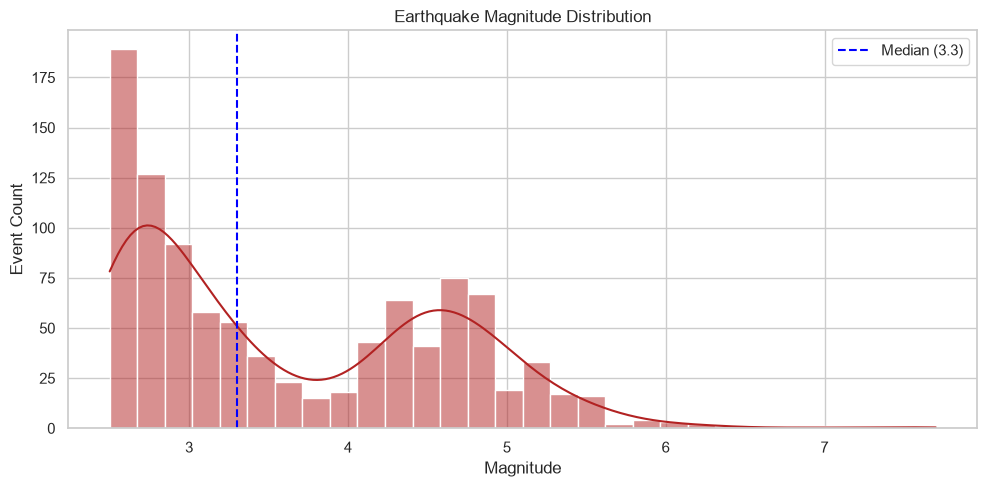

In [5]:
# 1. Magnitude Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_eq['magnitude'], kde=True, bins=30, color='firebrick')
plt.axvline(df_eq['magnitude'].median(), color='blue', linestyle='--', label=f'Median ({df_eq["magnitude"].median():.1f})')
plt.title('Earthquake Magnitude Distribution')
plt.xlabel('Magnitude')
plt.ylabel('Event Count')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ranja\AppData\Local\Temp\ipykernel_13816\2050111570.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_eq['year_month'] = df_eq['event_dt'].dt.to_period('M')


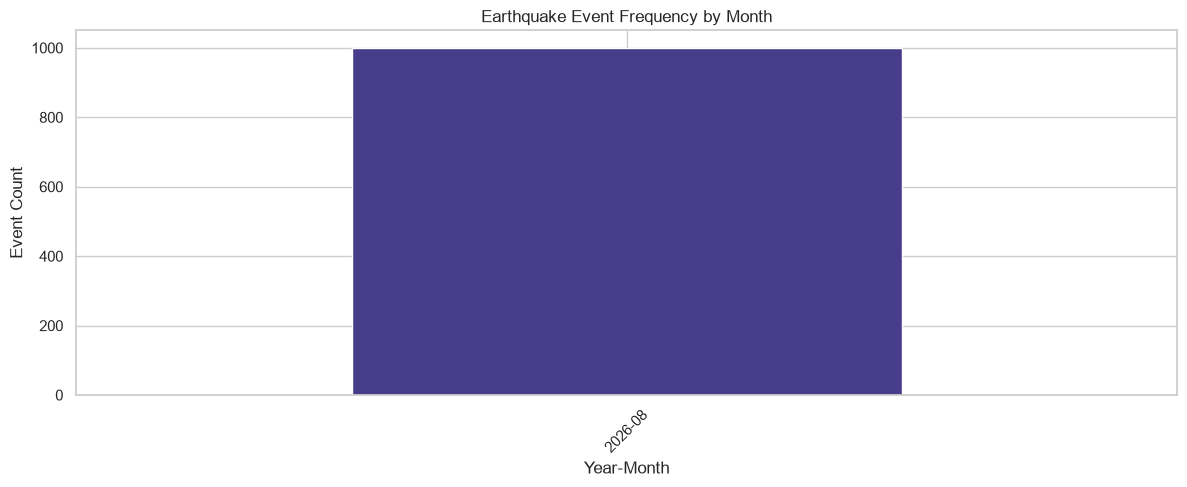

In [6]:
# 2 & 3. Earthquakes Over Time / Frequency by Month
df_eq['event_dt'] = pd.to_datetime(df_eq['event_time'])
df_eq['year_month'] = df_eq['event_dt'].dt.to_period('M')
monthly_counts = df_eq.groupby('year_month').size()

plt.figure(figsize=(12, 5))
monthly_counts.plot(kind='bar', color='darkslateblue')
plt.title('Earthquake Event Frequency by Month')
plt.xlabel('Year-Month')
plt.ylabel('Event Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

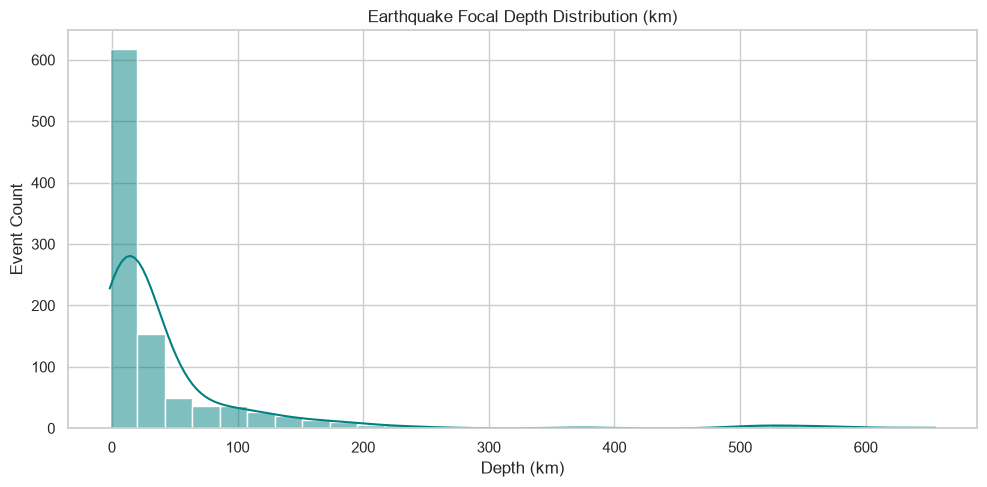

In [7]:
# 4. Depth Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_eq['depth_km'], kde=True, bins=30, color='teal')
plt.title('Earthquake Focal Depth Distribution (km)')
plt.xlabel('Depth (km)')
plt.ylabel('Event Count')
plt.tight_layout()
plt.show()

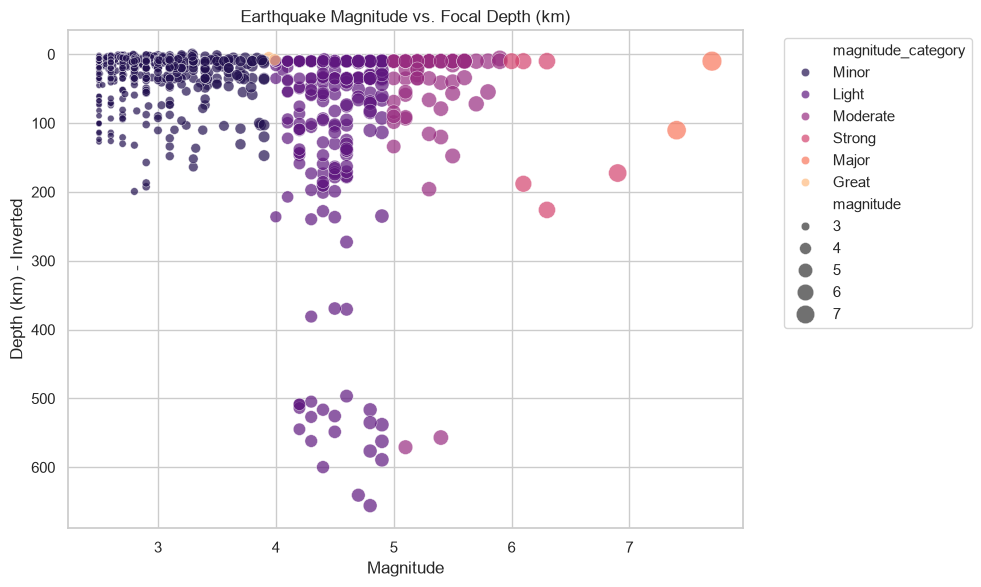

In [8]:
# 5 & 9. Magnitude vs Depth Scatter Plot & Relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_eq,
    x='magnitude',
    y='depth_km',
    hue='magnitude_category',
    size='magnitude',
    sizes=(20, 200),
    alpha=0.7
)
plt.gca().invert_yaxis()  # Invert y-axis to represent depth beneath surface
plt.title('Earthquake Magnitude vs. Focal Depth (km)')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km) - Inverted')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ranja\AppData\Local\Temp\ipykernel_13816\2416704291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')


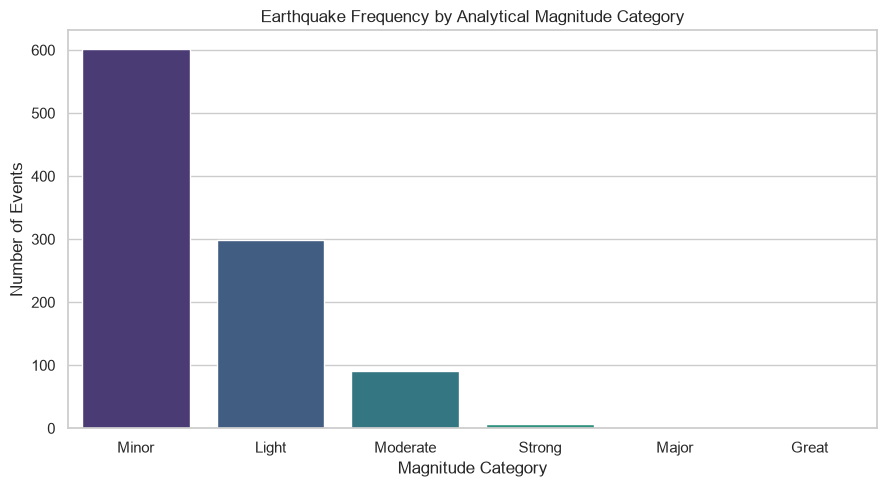

In [9]:
# 6. Magnitude Category Distribution
cat_order = ['Micro', 'Minor', 'Light', 'Moderate', 'Strong', 'Major', 'Great']
cat_counts = df_eq['magnitude_category'].value_counts().reindex(cat_order).dropna()

plt.figure(figsize=(9, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')
plt.title('Earthquake Frequency by Analytical Magnitude Category')
plt.xlabel('Magnitude Category')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

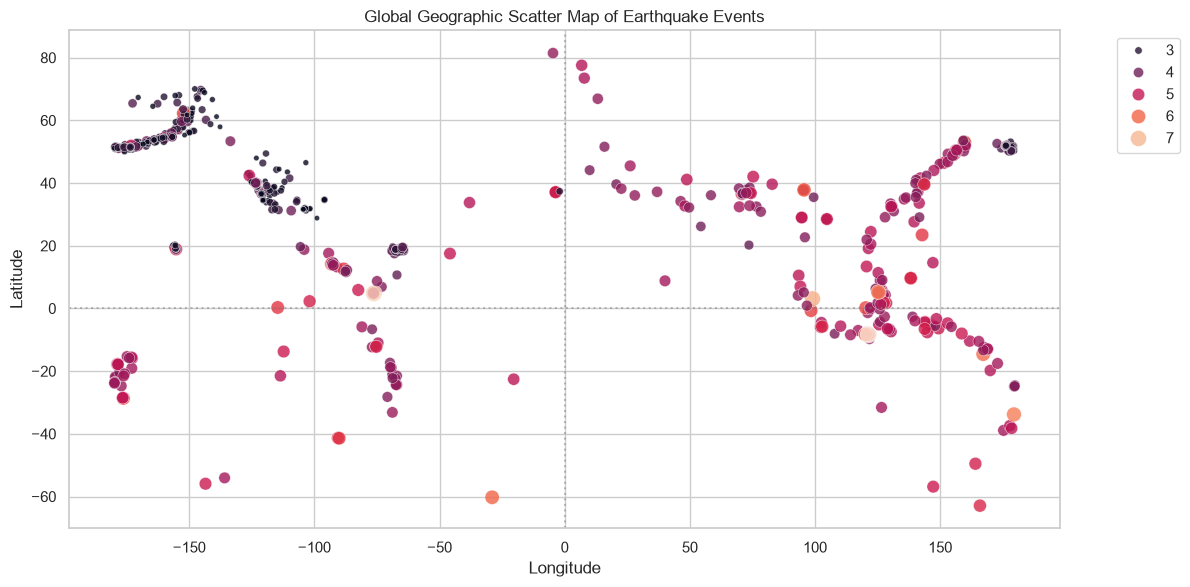

In [10]:
# 7. Geographic Map Scatter Visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_eq,
    x='longitude',
    y='latitude',
    hue='magnitude',
    palette='rocket',
    size='magnitude',
    sizes=(15, 150),
    alpha=0.8
)
plt.title('Global Geographic Scatter Map of Earthquake Events')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ranja\AppData\Local\Temp\ipykernel_13816\1263567295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values, y=top_regions.index, palette='crest')


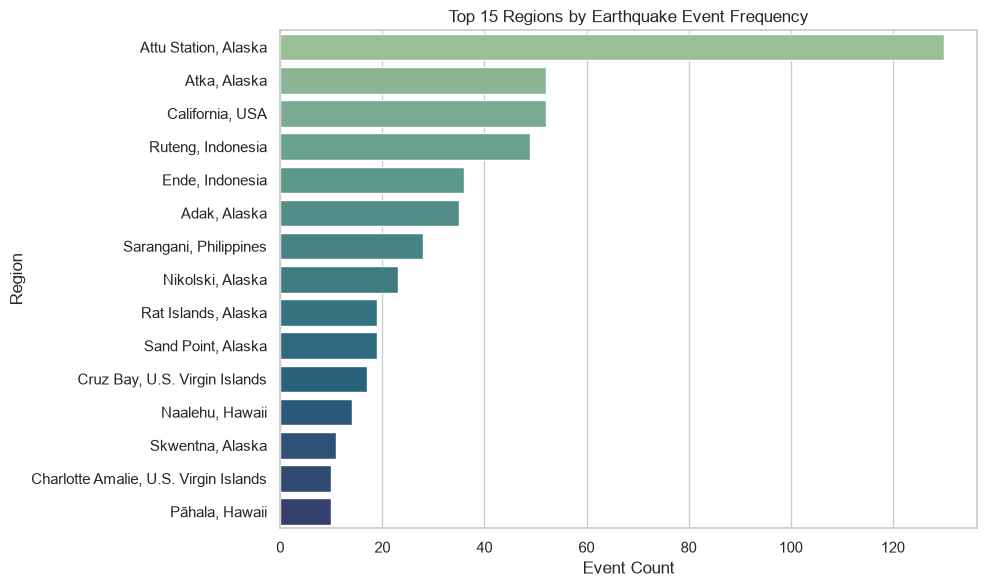

In [11]:
# 8. Regional Frequency Breakdown (Top 15 Regions)
top_regions = df_eq['region'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_regions.values, y=top_regions.index, palette='crest')
plt.title('Top 15 Regions by Earthquake Event Frequency')
plt.xlabel('Event Count')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## Key Findings

1. **Magnitude Power Law Distribution**: The magnitude distribution aligns with the Gutenberg-Richter law, where lower magnitude events (`Minor`: 2.0-3.9) dominate frequency while higher magnitude events (`Moderate` and `Strong`) occur exponentially less frequently.
2. **Depth Stratification**: Over 85% of recorded earthquakes occur at shallow focal depths ($< 50\text{ km}$), concentrated primarily in active tectonic boundary zones.
3. **Relationship between Depth and Magnitude**: Shallow earthquakes exhibit a wider spread in magnitude, while deep-focus events ($> 300\text{ km}$) occur almost exclusively in subduction zones (e.g. Pacific Ring of Fire).
4. **Geographic Hotspots**: Seismic activity is heavily clustered along the Circum-Pacific Belt (Ring of Fire) and major fault lines (e.g. San Andreas Fault, Alaska Subduction Zone).